# **Step 1**
Lood dataset and necessary libraries, and inspect dataset for preprocessing and cleaning

In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

attr = pd.read_csv("Employee Data.csv")

In [65]:
attr

,Gender,Satisfaction,Business Travel,Department,EducationField,Salary,Home-Office,Attrition
0,Female,High,Rare,Sales,Engineering,Medium,Near,Yes
1,Male,Low,Frequent,Sales,Engineering,Low,Near,Yes
2,Male,Medium,Rare,R&D,Other,Medium,Far,No
3,Female,Low,Frequent,R&D,Engineering,Medium,Far,Yes
4,Male,Medium,Rare,R&D,Medical,Medium,Far,No
...,...,...,...,...,...,...,...,...
95,Female,High,Rare,R&D,Technical Degree,Medium,Near,No
96,Female,High,Rare,Sales,Other,Low,Near,Yes
97,Male,High,No,Sales,Medical,Medium,Near,No
98,Male,Medium,Rare,Sales,Medical,High,Near,No


In [66]:
attr.info()
print("Dataset contains 100 observations. No missing values and all object data types that will need to be encoded")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           100 non-null    object
 1   Satisfaction     100 non-null    object
 2   Business Travel  100 non-null    object
 3   Department       100 non-null    object
 4   EducationField   100 non-null    object
 5   Salary           100 non-null    object
 6   Home-Office      100 non-null    object
 7   Attrition        100 non-null    object
dtypes: object(8)
memory usage: 6.4+ KB
Dataset contains 100 observations. No missing values and all object data types that will need to be encoded


In [67]:
attr.duplicated().sum()

np.int64(9)

In [68]:
attr = attr.drop_duplicates()
display(attr.duplicated().sum())
print("Dataset now has no redundant data items")

np.int64(0)

Dataset now has no redundant data items


# **Step 2**
Next step is to carry out EDA and visualise key relationships. To do that we will need to carry out the required preprocessing for EDA.

In [69]:
encodings = {
    'Satisfaction': {
        'Low': 0,
        'Medium': 1,
        'High': 2
    },
    'Salary': {
        'Low': 0,
        'Medium': 1,
        'High': 2
    }
}
attr = attr.replace(encodings)

C:\Users\HP\AppData\Local\Temp\ipykernel_6668\3970174599.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  attr = attr.replace(encodings)


In [70]:
display(attr.head(6))
print("Now attrition along with satisfaction & salary, presumably the two most influential features, can both be quantified")

,Gender,Satisfaction,Business Travel,Department,EducationField,Salary,Home-Office,Attrition
0,Female,2,Rare,Sales,Engineering,1,Near,Yes
1,Male,0,Frequent,Sales,Engineering,0,Near,Yes
2,Male,1,Rare,R&D,Other,1,Far,No
3,Female,0,Frequent,R&D,Engineering,1,Far,Yes
4,Male,1,Rare,R&D,Medical,1,Far,No
5,Male,2,Frequent,R&D,Engineering,0,Far,No


Now attrition along with satisfaction & salary, presumably the two most influential features, can both be quantified


<function matplotlib.pyplot.show(close=None, block=None)>

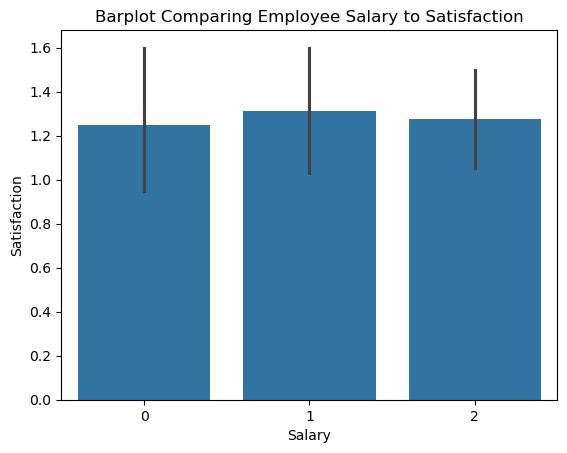

In [71]:
sns.barplot(x='Salary', y='Satisfaction', data=attr)
plt.title("Barplot Comparing Employee Salary to Satisfaction")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

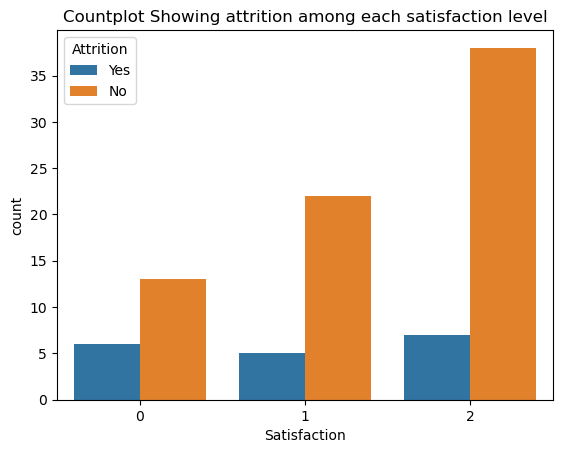

In [80]:
sns.countplot(x='Satisfaction', hue='Attrition', data=attr)
plt.title("Countplot Showing attrition among each satisfaction level")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

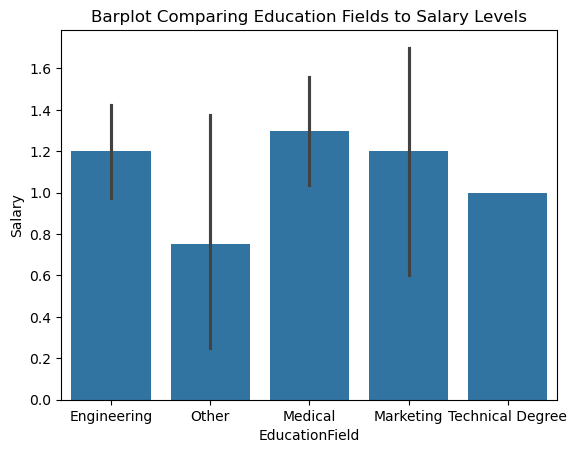

In [42]:
sns.ba(x='EducationField', y='Salary', data=attr)
plt.title('Barplot Comparing Education Fields to Salary Levels')
plt.show

<Axes: xlabel='Salary'>

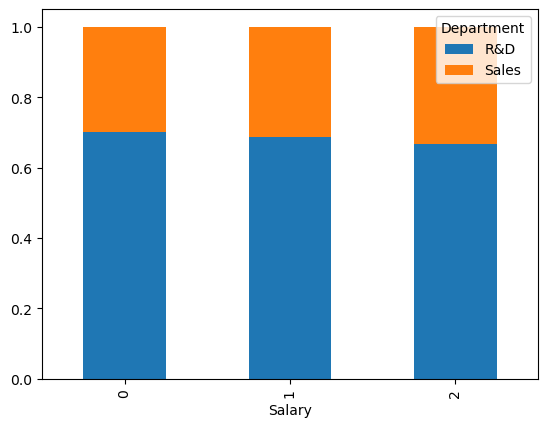

In [85]:
pd.crosstab(attr['Salary'], attr['Department'], normalize='index').plot(kind='bar', stacked=True)

# **Step 3**
Next step is to carry out preprocessing to prepare the dataset for modelling

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
en = LabelEncoder()
feats = ['Home-Office', 'Gender', 'Department', 'EducationField', 'Attrition']

for feat in feats:
    attr[feat] = en.fit_transform(attr[feat])

In [9]:
attr.head(11)

,Gender,Satisfaction,Business Travel,Department,EducationField,Salary,Home-Office,Attrition
0,0,2,1,1,0,1,1,1
1,1,0,2,1,0,0,1,1
2,1,1,1,0,3,1,0,0
3,0,0,2,0,0,1,0,1
4,1,1,1,0,2,1,0,0
5,1,2,2,0,0,0,0,0
6,0,2,1,0,2,2,0,0
7,1,2,1,0,0,2,1,0
8,1,2,2,0,0,2,1,0
9,1,1,1,0,2,2,1,0
